In [2]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
from pathlib import Path

In [9]:
# root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon"
# scenario_name = "old_params_extensive"
root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem"
scenario_name = "big_overview_20_10000p"

root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_2024_final"
scenario_name = "big_overview_20_10000p_fine_g1fix_relay"

root_output_directory = "/Net/Groups/BSI/scratch/ppapastefanou/simulations/SimPHony/swiss_cc/"
scenario_name = "18_ex_con_2025_full_logit_mean_one"

In [10]:
#scenario_name = "r2000_a20"
input_path = os.path.join(root_output_directory, scenario_name, 'input')
output_path = os.path.join(root_output_directory, scenario_name, 'output')
post_path = os.path.join(root_output_directory, scenario_name, 'post')

In [11]:
vars_total = ['psi_leaf_50_close','stem_hydraulic_capacitance', 'k_xylem_sat','huber_value',  'leaf_hydraulic_capacitance', 'psi50_xylem' ,'psi88_xylem','g0', 'k_soil_sat0', 'psi_soil_sat0','jackson_root_beta',  'pore_0', 'root_area_index', 'wcont_sigma_deviation', 'alpha', 'gam_stem_x_H','k_xyl_x_H', 'gam_stem_div_g0', 'g_min_loss']
vars_plant = ['psi_leaf_50_close','stem_hydraulic_capacitance', 'k_xylem_sat','huber_value', 'leaf_hydraulic_capacitance', 'psi50_xylem','psi88_xylem' ,'g0', 'alpha']
vars_plant_ex = ['psi_leaf_50_close','stem_hydraulic_capacitance', 'k_xylem_sat','huber_value', 'leaf_hydraulic_capacitance', 'psi50_xylem','psi88_xylem' ,'g0', 'alpha', 'gam_stem_x_H','k_xyl_x_H', 'gam_stem_div_g0', 'g_min_loss']

In [12]:
df = pd.read_csv(os.path.join(post_path, "aggregated_out.csv"))
df['alpha'] = df['g_stem_res']/ df['g0']
df['gam_stem_x_H'] = df['stem_hydraulic_capacitance'] * df['huber_value']
df['k_xyl_x_H'] = df['k_xylem_sat'] * df['huber_value']
df['gam_stem_div_g0'] = df['stem_hydraulic_capacitance']/ df['g0']
df['g_min_loss'] = df['g0'] + df['g_stem_res']
df.sort_values(by=['RMSE_MAX'], inplace=True, ascending=True)
df = df[df['RMSE_MAX'] < 1.1]
# index_to_drop = df[(df['sid'] == 2) | (df['sid'] == 2)].index
# df.drop(index_to_drop, inplace=True)
df_mean = df.groupby(['id'])[vars_total].mean()
df_mean.shape


(5956, 19)

In [69]:
df_mean

,psi_leaf_50_close,stem_hydraulic_capacitance,k_xylem_sat,huber_value,leaf_hydraulic_capacitance,psi50_xylem,psi88_xylem,g0,k_soil_sat0,psi_soil_sat0,jackson_root_beta,pore_0,root_area_index,wcont_sigma_deviation,alpha,gam_stem_x_H,k_xyl_x_H,gam_stem_div_g0,g_min_loss
id,,,,,,,,,,,,,,,,,,,
0,-0.895583,7044.009376,72.217238,0.000346,0.097608,-3.647942,-4.842357,0.001087,0.000012,-1.570480,0.956939,0.270303,9.140678,0.102669,0.010923,2.450291,0.024981,6.551873e+06,0.001099
2,-0.994237,18464.837807,82.599612,0.000264,0.060017,-3.639802,-4.809820,0.001280,0.000015,-1.933518,0.949022,0.255180,10.935925,-0.803448,0.290816,4.880587,0.021752,1.486926e+07,0.001644
6,-0.830771,15751.733084,62.258948,0.000262,0.121094,-3.757121,-4.965676,0.001095,0.000009,-1.872856,0.953186,0.269260,10.267024,-0.709947,0.727381,4.157479,0.016304,1.456041e+07,0.001893
9,-0.907400,24596.106550,75.622953,0.000251,0.063879,-3.798519,-5.030877,0.001466,0.000009,-1.846956,0.955291,0.264668,7.517104,-0.632697,0.750153,6.222695,0.018998,1.700446e+07,0.002563
10,-1.047256,13779.199315,77.241719,0.000354,0.098703,-3.819159,-4.942968,0.001464,0.000014,-1.746564,0.937828,0.276557,10.516732,-0.517949,0.325177,4.887741,0.027294,9.498980e+06,0.001939
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23535,-1.038130,11637.341199,78.742214,0.000341,0.078631,-3.728632,-4.945030,0.001236,0.000015,-1.658877,0.945513,0.264640,7.631078,0.098778,0.950013,3.962248,0.026828,9.450773e+06,0.002402
23536,-0.799039,11205.535957,76.509907,0.000319,0.123432,-3.770777,-4.991117,0.000966,0.000013,-1.777526,0.962940,0.264766,11.704728,-0.504594,0.238498,3.568006,0.024303,1.185442e+07,0.001192
23544,-0.883199,23705.450948,83.284327,0.000239,0.118801,-3.761484,-4.902147,0.001381,0.000011,-2.080156,0.943320,0.254613,10.869595,-0.475158,0.443206,5.697788,0.019923,1.759287e+07,0.001982


In [13]:
def round_sigfig(num, sig_figs):
    """Rounds a number to a specified number of significant figures.

    Args:
        num: The number to round.
        sig_figs: The number of significant figures.

    Returns:
        The rounded number.
    """

    if num == 0:
        return 0
    else:
        return round(num, sig_figs - int(np.floor(np.log10(abs(num)))) - 1)
    

In [28]:
df

,Unnamed: 0,index,id,root_area_index,canopy_height,dts,dts_input,verbose,max_psi_leaf_change_per_hour,minimum_psi_leaf_multiplier,...,t9,t10,t11,t12,t13,alive_mean,target_rmse,RMSE_MAX,sid,alpha
43679,4,2214,8735,8.119745,35,1800.0,1800,False,1.0,1.75,...,6.521233,4.111703,4.373466,4.087206,4.066384,4.509504,0.864514,0.960135,4,0.087368
43675,0,9932,8735,8.050982,35,1800.0,1800,False,1.0,1.75,...,0.206691,0.508489,0.442251,0.581101,0.504654,0.460865,0.864514,0.960135,0,0.169586
43677,2,9563,8735,11.038087,35,1800.0,1800,False,1.0,1.75,...,2.114277,1.135614,1.257858,1.101552,1.025798,1.295194,0.864514,0.960135,2,0.135692
43676,1,4780,8735,10.719259,35,1800.0,1800,False,1.0,1.75,...,7.773502,3.916602,4.133199,3.896701,3.830970,4.501504,0.864514,0.960135,1,0.128629
43678,3,3499,8735,8.105408,35,1800.0,1800,False,1.0,1.75,...,6.891925,4.017259,4.259368,3.992932,3.972117,4.477188,0.864514,0.960135,3,0.127727
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64364,4,947,12872,7.030513,35,1800.0,1800,False,1.0,1.75,...,6.525837,4.105730,4.364538,4.082846,4.061413,4.504796,0.891477,1.099963,4,0.947624
64361,1,3247,12872,5.322844,35,1800.0,1800,False,1.0,1.75,...,8.057371,3.987361,4.202243,3.970485,3.901336,4.602189,0.891477,1.099963,1,1.020370
64363,3,3644,12872,7.023277,35,1800.0,1800,False,1.0,1.75,...,6.436254,3.723736,3.947455,3.701301,3.678031,4.157812,0.891477,1.099963,3,0.651423
64360,0,9521,12872,6.830330,35,1800.0,1800,False,1.0,1.75,...,0.331746,0.557500,0.525518,0.611146,0.534778,0.527982,0.891477,1.099963,0,0.879952


In [14]:
vars_sel = ['stem_hydraulic_capacitance', 'k_xylem_sat','huber_value', 'psi50_xylem','ps88_xylem','g0', 'alpha','psi_leaf_50_close']
vars_sel = vars_plant
label_dict  = {}
label_dict['huber_value'] = r"Huber $\mathcal{H}$"
label_dict['stem_hydraulic_capacitance'] = r"$\Gamma_\mathrm{Stem}$"
label_dict['leaf_hydraulic_capacitance'] = r"$\Gamma_\mathrm{Leaf}$"
label_dict['g0'] = r"$g_0$"
label_dict['g1'] = r"$g_1$"
label_dict['k_xylem_sat'] = r"$K_\mathrm{xyl, max}$"
label_dict['psi50_xylem'] = r"$\psi_{50}$"
label_dict['psi88_xylem'] = r"$\psi_{88}$"
label_dict['wcont_sigma_deviation'] = r"$\sigma_\mathrm{wcont}$"
label_dict['pore_0'] = r"$\xi$"
label_dict['jackson_root_beta'] = r"$\mathrm{Root}_\beta$"
label_dict['psi_leaf_50_close'] = r"$\psi_{Leaf, close}$"
label_dict['d_50_close'] = r"$d_{Leaf, close}$"
label_dict['alpha'] = r"$\alpha$"
label_dict['gam_stem_x_H'] = r"$\Gamma_\mathrm{Stem} \cdot \mathcal{H}$"
label_dict['gam_stem_div_g0'] = r"$\frac{\Gamma_\mathrm{Stem}}{g_0}$"
label_dict['k_xyl_x_H'] = r"$K_\mathrm{xyl, max}\cdot \mathcal{H}$"
label_dict['g_min_loss'] = r"$g_0 + g_\mathrm{Bark}$"


unit_dict= {}
unit_dict['stem_hydraulic_capacitance'] = "kg m-3 MPa-1"
unit_dict['leaf_hydraulic_capacitance'] = "kg m-2 MPa-1"
unit_dict['k_xylem_sat'] = "kg m-1 s-1 MPa-1"
unit_dict['huber_value'] = "-"
unit_dict['psi50_xylem'] = "MPa"
unit_dict['psi88_xylem'] = "MPa"
unit_dict['g0'] = "mol m-1 s-1"
unit_dict['g1'] = "-"
unit_dict['g_stem_res'] = "mol m-1 s-1"
unit_dict['psi_leaf_50_close'] = r"MPa"
unit_dict['d_50_close'] = "-"
unit_dict['alpha'] = r"-"
unit_dict['gam_stem_x_H'] = r"-"
unit_dict['gam_stem_div_g0'] = r"-"
unit_dict['k_xyl_x_H'] =r"-"
unit_dict['g_min_loss'] = r"-"


In [32]:
df_mean

,psi_leaf_50_close,stem_hydraulic_capacitance,k_xylem_sat,huber_value,leaf_hydraulic_capacitance,psi50_xylem,psi88_xylem,g0,k_soil_sat0,psi_soil_sat0,jackson_root_beta,pore_0,root_area_index,wcont_sigma_deviation,alpha,gam_stem_div_H,k_xyl_div_H,gam_stem_x_g0,g_min_loss
id,,,,,,,,,,,,,,,,,,,
0,-0.895583,7044.009376,72.217238,0.000346,0.097608,-3.647942,-4.842357,0.001087,0.000012,-1.570480,0.956939,0.270303,9.140678,0.102669,0.010923,2.033238e+07,209747.693023,7.614406,0.001099
2,-0.994237,18464.837807,82.599612,0.000264,0.060017,-3.639802,-4.809820,0.001280,0.000015,-1.933518,0.949022,0.255180,10.935925,-0.803448,0.290816,7.040857e+07,316197.700601,23.412713,0.001644
6,-0.830771,15751.733084,62.258948,0.000262,0.121094,-3.757121,-4.965676,0.001095,0.000009,-1.872856,0.953186,0.269260,10.267024,-0.709947,0.727381,6.035105e+07,240280.185961,17.183663,0.001893
9,-0.907400,24596.106550,75.622953,0.000251,0.063879,-3.798519,-5.030877,0.001466,0.000009,-1.846956,0.955291,0.264668,7.517104,-0.632697,0.750153,9.775825e+07,302890.324521,35.888441,0.002563
10,-1.047256,13779.199315,77.241719,0.000354,0.098703,-3.819159,-4.942968,0.001464,0.000014,-1.746564,0.937828,0.276557,10.516732,-0.517949,0.325177,3.886185e+07,218683.505907,20.185459,0.001939
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23535,-1.038130,11637.341199,78.742214,0.000341,0.078631,-3.728632,-4.945030,0.001236,0.000015,-1.658877,0.945513,0.264640,7.631078,0.098778,0.950013,3.419087e+07,231182.989881,14.397618,0.002402
23536,-0.799039,11205.535957,76.509907,0.000319,0.123432,-3.770777,-4.991117,0.000966,0.000013,-1.777526,0.962940,0.264766,11.704728,-0.504594,0.238498,3.551064e+07,242780.336662,10.801235,0.001192
23544,-0.883199,23705.450948,83.284327,0.000239,0.118801,-3.761484,-4.902147,0.001381,0.000011,-2.080156,0.943320,0.254613,10.869595,-0.475158,0.443206,9.930771e+07,350709.556567,32.527826,0.001982


<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1482251/3447439833.py:20: SyntaxWarning: invalid escape sequence '\m'
  ax.text(0.05,0.2,f"$\mu$ = {round_sigfig(data.median(),2)}", transform=ax.transAxes, bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'));
/tmp/ipykernel_1482251/3447439833.py:23: SyntaxWarning: invalid escape sequence '\s'
  ax.text(0.05,0.05,f"$\sigma$ = {round_sigfig(data.std(),2)}", transform=ax.transAxes,    bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'));


psi_leaf_50_close
stem_hydraulic_capacitance
k_xylem_sat
huber_value
leaf_hydraulic_capacitance
psi50_xylem
psi88_xylem
g0


findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.


alpha


findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

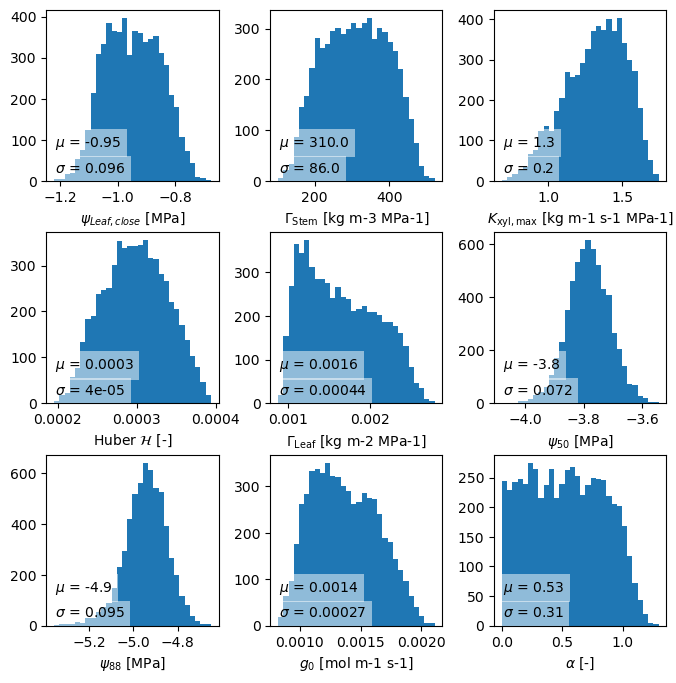

In [16]:
MOL_TO_KG = 18.0/1000.0
plt.rcParams["font.family"] = "Avenir"
fig = plt.figure(figsize=(8, 8))
i =1 
for var in vars_sel:
    ax = fig.add_subplot(3, 3, i)
    
    if  var == 'stem_hydraulic_capacitance':
        data = df_mean[var] * MOL_TO_KG
    elif  var == 'leaf_hydraulic_capacitance':
        data = df_mean[var] * MOL_TO_KG
    elif var == 'k_xylem_sat':
        data = df_mean[var] * MOL_TO_KG
    else:
        data = df_mean[var]
    
    ax.hist(data, alpha=1.0, bins=30);
    ax.set_xlabel(f"{label_dict[var]} [{unit_dict[var]}]")
    
    ax.text(0.05,0.2,f"$\mu$ = {round_sigfig(data.median(),2)}", transform=ax.transAxes, bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'));
    # ax.text(0.05,0.89,f"Q25 = {round_sigfig(data.quantile(q = 0.25),2)}", transform=ax.transAxes);
    # ax.text(0.05,0.84,f"Q75 = {round_sigfig(data.quantile(q = 0.75),2)}", transform=ax.transAxes);
    ax.text(0.05,0.05,f"$\sigma$ = {round_sigfig(data.std(),2)}", transform=ax.transAxes,    bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'));
    # if (i < 5 ) & (i!=2):
    #     ax.text(0.05,0.94,f"Median = {round_sigfig(data.median(),2)}", transform=ax.transAxes);
    #     ax.text(0.05,0.89,f"Q25 = {round_sigfig(data.quantile(q = 0.25),2)}", transform=ax.transAxes);
    #     ax.text(0.05,0.84,f"Q75 = {round_sigfig(data.quantile(q = 0.75),2)}", transform=ax.transAxes);
    #     ax.text(0.05,0.79,f"std = {round_sigfig(data.std(),2)}", transform=ax.transAxes);
    # else:
    #     ax.text(0.6,0.94,f"Median = {round_sigfig(data.median(),2)}", transform=ax.transAxes);
    #     ax.text(0.6,0.89,f"Q25 = {round_sigfig(data.quantile(q = 0.25),2)}", transform=ax.transAxes);
    #     ax.text(0.6,0.84,f"Q75 = {round_sigfig(data.quantile(q = 0.75),2)}", transform=ax.transAxes);
    #     ax.text(0.6,0.79,f"std = {round_sigfig(data.std(),2)}", transform=ax.transAxes);

    ax.grid(False)
    ax.set_xlabel(f"{label_dict[var]} [{unit_dict[var]}]")
    i+=1
    print(var)
plt.subplots_adjust(hspace=0.3, wspace=0.3)
plt.savefig(f"{post_path}/figure3_selective_variables.png", bbox_inches='tight', dpi = 300)
plt.show()
# plt.close(fig)


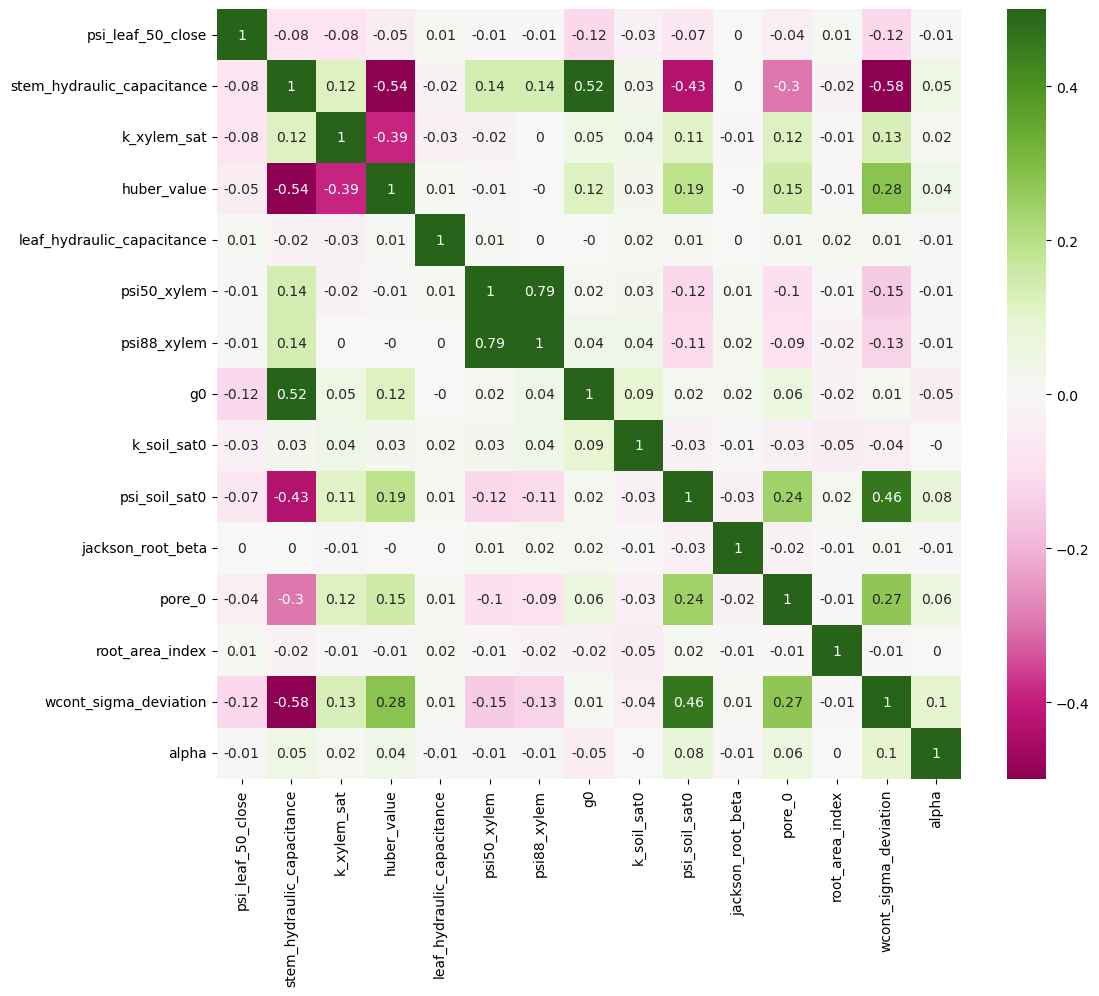

In [13]:
import seaborn as sns
from sklearn.metrics import silhouette_score
corr_matrix = df_mean.corr(method='spearman').round(2)
#corr_matrix.style.background_gradient(cmap='Greens')
plt.figure(figsize = (12,10))
sns.heatmap(corr_matrix, annot=True, vmin=-0.5, vmax=0.5, cmap="PiYG")
plt.savefig(f"{post_path}/figure_corelation4.png", bbox_inches='tight', dpi = 300)

In [66]:
df_mean

,psi_leaf_50_close,stem_hydraulic_capacitance,k_xylem_sat,huber_value,leaf_hydraulic_capacitance,psi50_xylem,psi88_xylem,g0,k_soil_sat0,psi_soil_sat0,jackson_root_beta,pore_0,root_area_index,wcont_sigma_deviation,alpha
id,,,,,,,,,,,,,,,
0,-0.895583,7044.009376,72.217238,0.000346,0.097608,-3.647942,-4.842357,0.001087,0.000012,-1.570480,0.956939,0.270303,9.140678,0.102669,0.010923
2,-0.994237,18464.837807,82.599612,0.000264,0.060017,-3.639802,-4.809820,0.001280,0.000015,-1.933518,0.949022,0.255180,10.935925,-0.803448,0.290816
6,-0.830771,15751.733084,62.258948,0.000262,0.121094,-3.757121,-4.965676,0.001095,0.000009,-1.872856,0.953186,0.269260,10.267024,-0.709947,0.727381
9,-0.907400,24596.106550,75.622953,0.000251,0.063879,-3.798519,-5.030877,0.001466,0.000009,-1.846956,0.955291,0.264668,7.517104,-0.632697,0.750153
10,-1.047256,13779.199315,77.241719,0.000354,0.098703,-3.819159,-4.942968,0.001464,0.000014,-1.746564,0.937828,0.276557,10.516732,-0.517949,0.325177
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23535,-1.038130,11637.341199,78.742214,0.000341,0.078631,-3.728632,-4.945030,0.001236,0.000015,-1.658877,0.945513,0.264640,7.631078,0.098778,0.950013
23536,-0.799039,11205.535957,76.509907,0.000319,0.123432,-3.770777,-4.991117,0.000966,0.000013,-1.777526,0.962940,0.264766,11.704728,-0.504594,0.238498
23544,-0.883199,23705.450948,83.284327,0.000239,0.118801,-3.761484,-4.902147,0.001381,0.000011,-2.080156,0.943320,0.254613,10.869595,-0.475158,0.443206


<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_4128261/1035876893.py:20: SyntaxWarning: invalid escape sequence '\m'
  ax.text(0.05,0.26,f"$\mu$ = {round_sigfig(data.median(),2)}", transform=ax.transAxes, bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'));


psi_leaf_50_close
stem_hydraulic_capacitance
k_xylem_sat
huber_value
leaf_hydraulic_capacitance
psi50_xylem
psi88_xylem
g0
alpha


findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.


gam_stem_x_H
k_xyl_x_H
gam_stem_div_g0
g_min_loss


findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

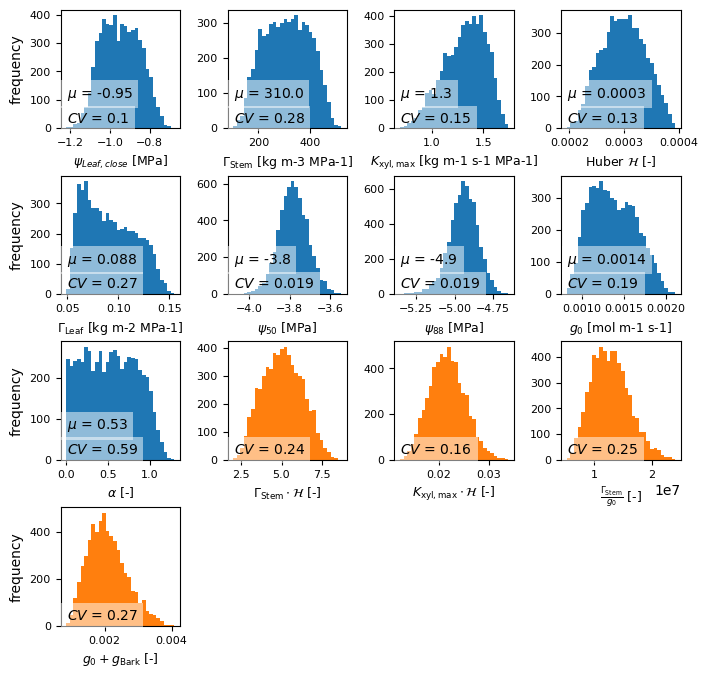

In [13]:
MOL_TO_KG = 18.0/1000.0
plt.rcParams["font.family"] = "Avenir"
fig = plt.figure(figsize=(8, 8))
i =1 
vars_sel = vars_plant_ex
for var in vars_sel:
    ax = fig.add_subplot(4, 4, i)
    
    if  var == 'stem_hydraulic_capacitance':
        data = df_mean[var] * MOL_TO_KG
    elif var == 'k_xylem_sat':
        data = df_mean[var] * MOL_TO_KG
    else:
        data = df_mean[var]
    

    ax.set_xlabel(f"{label_dict[var]} [{unit_dict[var]}]", fontsize=9)
    
    if i < 10:
        ax.text(0.05,0.26,f"$\mu$ = {round_sigfig(data.median(),2)}", transform=ax.transAxes, bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'));
        ax.hist(data, alpha=1.0, bins=30, color= 'tab:blue');
    else:
        ax.hist(data, alpha=1.0, bins=30, color= 'tab:orange');
    # ax.text(0.05,0.89,f"Q25 = {round_sigfig(data.quantile(q = 0.25),2)}", transform=ax.transAxes);
    # ax.text(0.05,0.84,f"Q75 = {round_sigfig(data.quantile(q = 0.75),2)}", transform=ax.transAxes);
    ax.text(0.05,0.05,f"$CV$ = {round_sigfig(abs(data.std()/data.mean()),2)}", transform=ax.transAxes,    bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'));
    ax.tick_params(axis='both', labelsize=8)  
    if i % 4 == 1:
        ax.set_ylabel("frequency")  
    # if (i < 5 ) & (i!=2):
    #     ax.text(0.05,0.94,f"Median = {round_sigfig(data.median(),2)}", transform=ax.transAxes);
    #     ax.text(0.05,0.89,f"Q25 = {round_sigfig(data.quantile(q = 0.25),2)}", transform=ax.transAxes);
    #     ax.text(0.05,0.84,f"Q75 = {round_sigfig(data.quantile(q = 0.75),2)}", transform=ax.transAxes);
    #     ax.text(0.05,0.79,f"std = {round_sigfig(data.std(),2)}", transform=ax.transAxes);
    # else:
    #     ax.text(0.6,0.94,f"Median = {round_sigfig(data.median(),2)}", transform=ax.transAxes);
    #     ax.text(0.6,0.89,f"Q25 = {round_sigfig(data.quantile(q = 0.25),2)}", transform=ax.transAxes);
    #     ax.text(0.6,0.84,f"Q75 = {round_sigfig(data.quantile(q = 0.75),2)}", transform=ax.transAxes);
    #     ax.text(0.6,0.79,f"std = {round_sigfig(data.std(),2)}", transform=ax.transAxes);

    ax.grid(False)
    i+=1
    print(var)
plt.subplots_adjust(hspace=0.4, wspace=0.4)
plt.savefig(f"{post_path}/figure3b_selective_variables_ex.png", bbox_inches='tight', dpi = 300)
plt.show()

(array([471., 351., 257., 138.,  54.,  15.,   1.,   0.,   0.]),
 array([6000., 6100., 6200., 6300., 6400., 6500., 6600., 6700., 6800.,
        6900.]),
 <BarContainer object of 9 artists>)

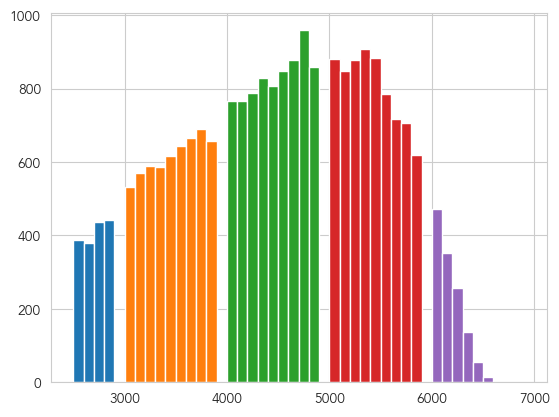

In [ ]:
dh = df_mean[df_mean['bins_kapp'] == pd.Interval(left=0, right=3000)]
plt.hist(dh['stem_hydraulic_capacitance'],bins=np.arange(2500,3000,100))
dh = df_mean[df_mean['bins_kapp'] == pd.Interval(left=3000, right=4000)]
plt.hist(dh['stem_hydraulic_capacitance'],bins=np.arange(3000,4000,100))
dh = df_mean[df_mean['bins_kapp'] == pd.Interval(left=4000, right=5000)]
plt.hist(dh['stem_hydraulic_capacitance'],bins=np.arange(4000,5000,100))
dh = df_mean[df_mean['bins_kapp'] == pd.Interval(left=5000, right=6000)]
plt.hist(dh['stem_hydraulic_capacitance'],bins=np.arange(5000,6000,100))
dh = df_mean[df_mean['bins_kapp'] == pd.Interval(left=6000, right=7000)]
plt.hist(dh['stem_hydraulic_capacitance'],bins=np.arange(6000,7000,100))

/Users/pp/anaconda3/envs/PHS-post/lib/python3.12/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


(array([[         nan,          nan,          nan,          nan,
                  nan,          nan,          nan],
        [852.44267198, 701.2296444 , 518.86008641, 333.58258558,
          92.22333001,   1.66168162,   0.        ],
        [705.64270947, 674.93615469, 554.54213791, 441.7487535 ,
         120.69804208,   2.43220236,   0.        ],
        [436.58028389, 598.71076963, 664.80010418, 604.57090767,
         190.45448626,   4.88344837,   0.        ],
        [130.14763015, 417.63791764, 695.41569542, 860.52836053,
         384.61538462,  11.65501166,   0.        ]]),
 array([0.001 , 0.0014, 0.0018, 0.0022, 0.0026, 0.003 , 0.0034, 0.0038]),
 <a list of 5 BarContainer objects>)

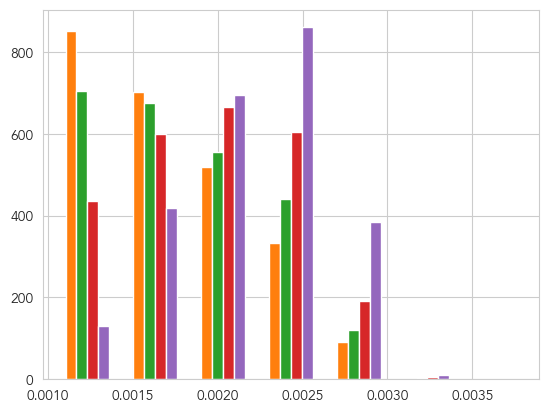

In [15]:
dh1 = df_mean[df_mean['bins_kapp'] == pd.Interval(left=2000, right=3000)]
dh2 = df_mean[df_mean['bins_kapp'] == pd.Interval(left=3000, right=4000)]
dh3 = df_mean[df_mean['bins_kapp'] == pd.Interval(left=4000, right=5000)]
dh4 = df_mean[df_mean['bins_kapp'] == pd.Interval(left=5000, right=6000)]
dh5 = df_mean[df_mean['bins_kapp'] == pd.Interval(left=6000, right=7000)]

plt.hist([dh1['g0'].values,
          dh2['g0'].values,
          dh3['g0'].values,
          dh4['g0'].values,
          dh5['g0'].values],
         bins=np.arange(0.001, 0.004,0.0004
                        ), histtype='bar', density=True)


In [53]:
import numpy as np
from scipy.stats import t

def cv_t_test(data1, data2):
    """
    Performs a t-test to compare the coefficients of variation (CV)
    of two independent samples.
    
    Args:
        data1 (array-like): First dataset.
        data2 (array-like): Second dataset.
        
    Returns:
        tuple: A tuple containing the t-statistic and the p-value.
    """
    data1 = np.asarray(data1)
    data2 = np.asarray(data2)

    # Calculate means, standard deviations, and sample sizes
    mean1, std1 = np.mean(data1), np.std(data1, ddof=1)
    mean2, std2 = np.mean(data2), np.std(data2, ddof=1)
    n1, n2 = len(data1), len(data2)

    # Check for validity
    if mean1 <= 0 or mean2 <= 0:
        raise ValueError("Mean must be greater than zero to calculate CV.")
    if n1 < 2 or n2 < 2:
        raise ValueError("Sample size must be at least 2.")

    # Calculate Coefficients of Variation
    cv1 = std1 / mean1
    cv2 = std2 / mean2

    # Calculate t-statistic (Feltz and Miller method)
    # The statistic is based on the log-transformed ratio of CVs
    numerator = np.log(cv1) - np.log(cv2)
    
    # The denominator is the standard error of the log-transformed CVs
    denominator = np.sqrt(
        (1 / (2 * (n1 - 1))) * (1 + cv1**2) +
        (1 / (2 * (n2 - 1))) * (1 + cv2**2)
    )

    t_statistic = numerator / denominator
    
    # Degrees of freedom for this test
    df = n1 + n2 - 2
    
    # Calculate p-value (two-tailed test)
    p_value = 2 * t.sf(np.abs(t_statistic), df)
    
    return t_statistic, p_value

In [54]:
t_stat, p_val  = cv_t_test(df_mean['stem_hydraulic_capacitance'], df_mean['gam_stem_div_H'])
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_val:.4f}")

T-Statistic: 10.1325
P-Value: 0.0000


In [57]:
t_stat, p_val  = cv_t_test(df_mean['k_xylem_sat'], df_mean['k_xyl_div_H'])
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_val:.4f}")

T-Statistic: -4.3822
P-Value: 0.0000
